In [ ]:
setwd("splicing")

library(plyr)
library(dplyr)
library(ggplot2)
library(data.table)

options(max.print=10000)
options(repr.plot.width=10, repr.plot.height=8)

In [ ]:
default_theme <- function() {
    theme_minimal() +
        theme(
            plot.title=element_text(size=18),
            plot.subtitle=element_text(size=14, margin=margin(b=15)),
            axis.title.x=element_text(margin=margin(t=10)),
            axis.title.y=element_text(margin=margin(r=10)),
            legend.direction="horizontal",
            legend.position="bottom",
            legend.title=element_blank(),
            legend.text=element_text(size=14),
            plot.margin=unit(c(2, 2, 2, 2), "cm")
        )
}

theme_set(default_theme())

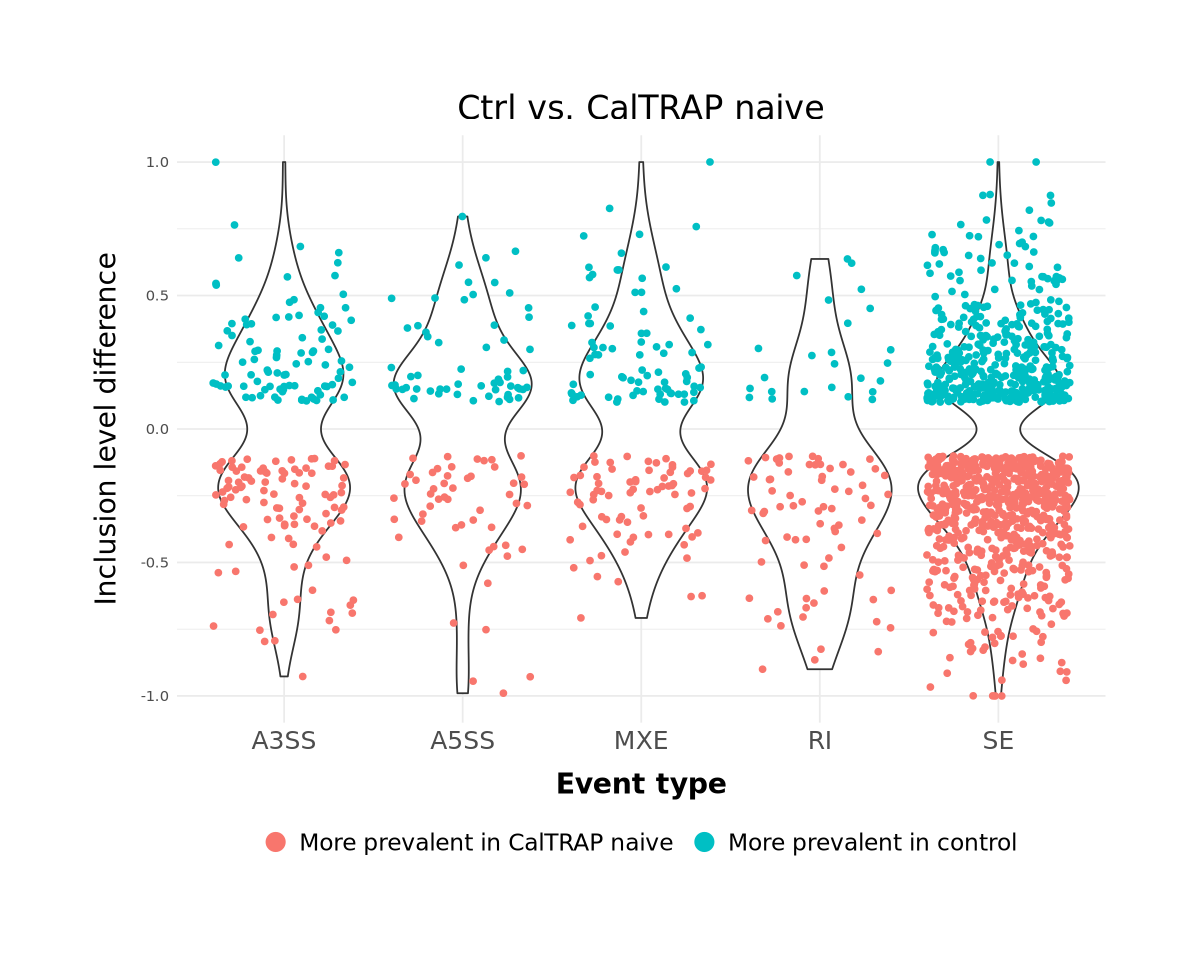

In [ ]:
# combine all singificant splicing events

experiment_path <- "data/rmats/ctrl_vs_naive"

signif_files <- list.files(path=experiment_path, pattern="filtered")

signif_events_list <- lapply(signif_files, function(x) {
    df <- fread(file.path(experiment_path, x), data.table=FALSE)
    df$Event_type <- unlist(strsplit(x, split=".", fixed=TRUE))[1]
    df
})
signif_events_df <- do.call(rbind.fill, signif_events_list)
signif_events_df$Status <- "More prevalent in CalTRAP naive"
signif_events_df$Status[signif_events_df$IncLevelDifference > 0] <- "More prevalent in control"

ggplot(signif_events_df, aes(x=Event_type, y=IncLevelDifference)) +
    geom_violin() +
    geom_jitter(aes(color=Status)) +
    theme(
        plot.title=element_text(size=20, hjust=.5),
        axis.title.x=element_text(size=17, face="bold"),
        axis.text.x=element_text(size=15),
        axis.title.y=element_text(size=17)
    ) +
    labs(title="Ctrl vs. CalTRAP naive") +
    xlab("Event type") +
    ylab("Inclusion level difference") +
    guides(color=guide_legend(override.aes=list(size=5)))

## Ctrl vs. CalTRAP AR

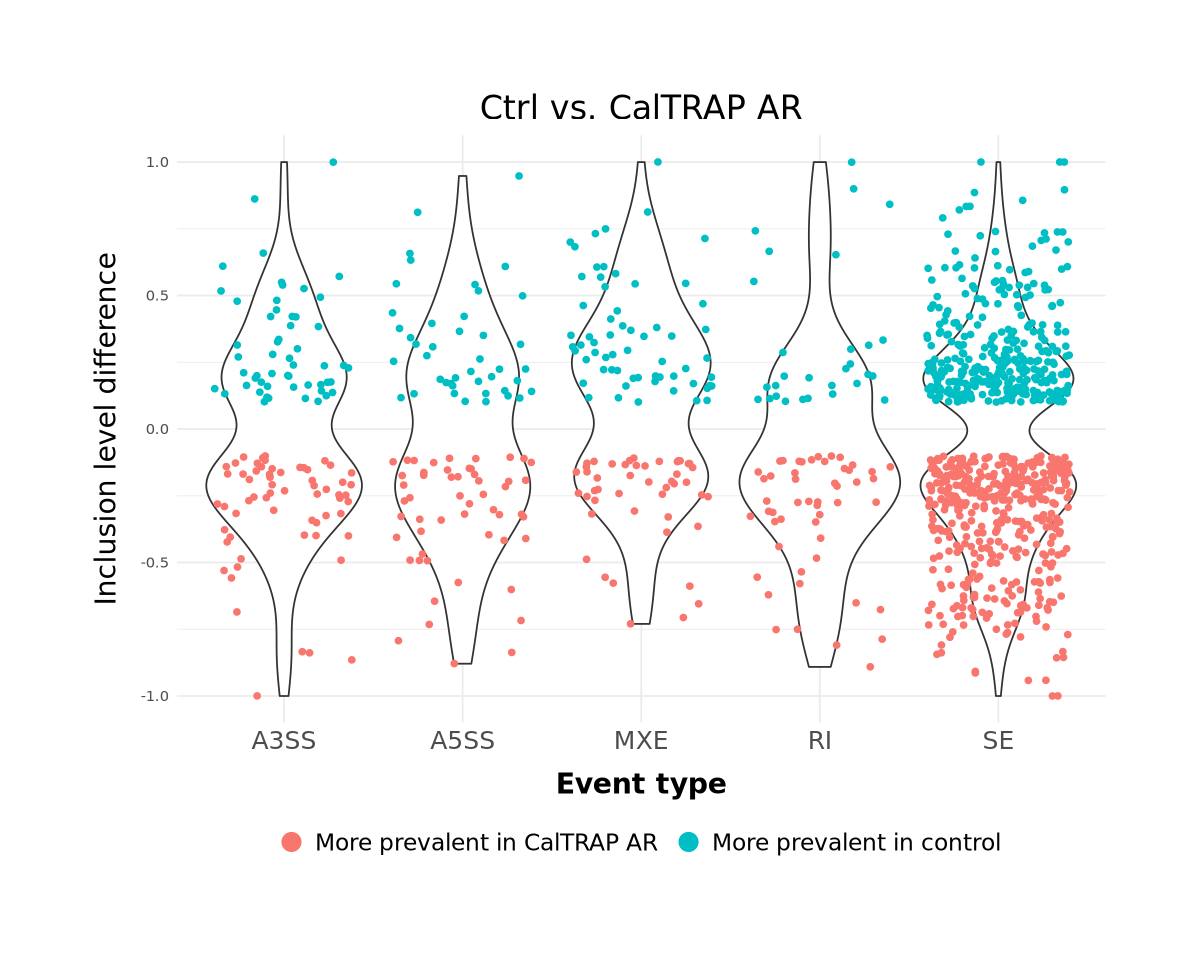

In [ ]:
# Combine all singificant splicing events

experiment_path <- "data/rmats/ctrl_vs_AR"

signif_files <- list.files(path=experiment_path, pattern="filtered")

signif_events_list <- lapply(signif_files, function(x) {
    df <- fread(file.path(experiment_path, x), data.table=FALSE)
    df$Event_type <- unlist(strsplit(x, split=".", fixed=TRUE))[1]
    df
})
signif_events_df <- do.call(rbind.fill, signif_events_list)
signif_events_df$Status <- "More prevalent in CalTRAP AR"
signif_events_df$Status[signif_events_df$IncLevelDifference > 0] <- "More prevalent in control"

ggplot(signif_events_df, aes(x=Event_type, y=IncLevelDifference)) +
    geom_violin() +
    geom_jitter(aes(color=Status)) +
    theme(
        plot.title=element_text(size=20, hjust=.5),
        axis.title.x=element_text(size=17, face="bold"),
        axis.text.x=element_text(size=15),
        axis.title.y=element_text(size=17)
    ) +
    labs(title="Ctrl vs. CalTRAP AR") +
    xlab("Event type") +
    ylab("Inclusion level difference") +
    guides(color=guide_legend(override.aes=list(size=5)))

## CalTRAP naive vs. CalTRAP AR

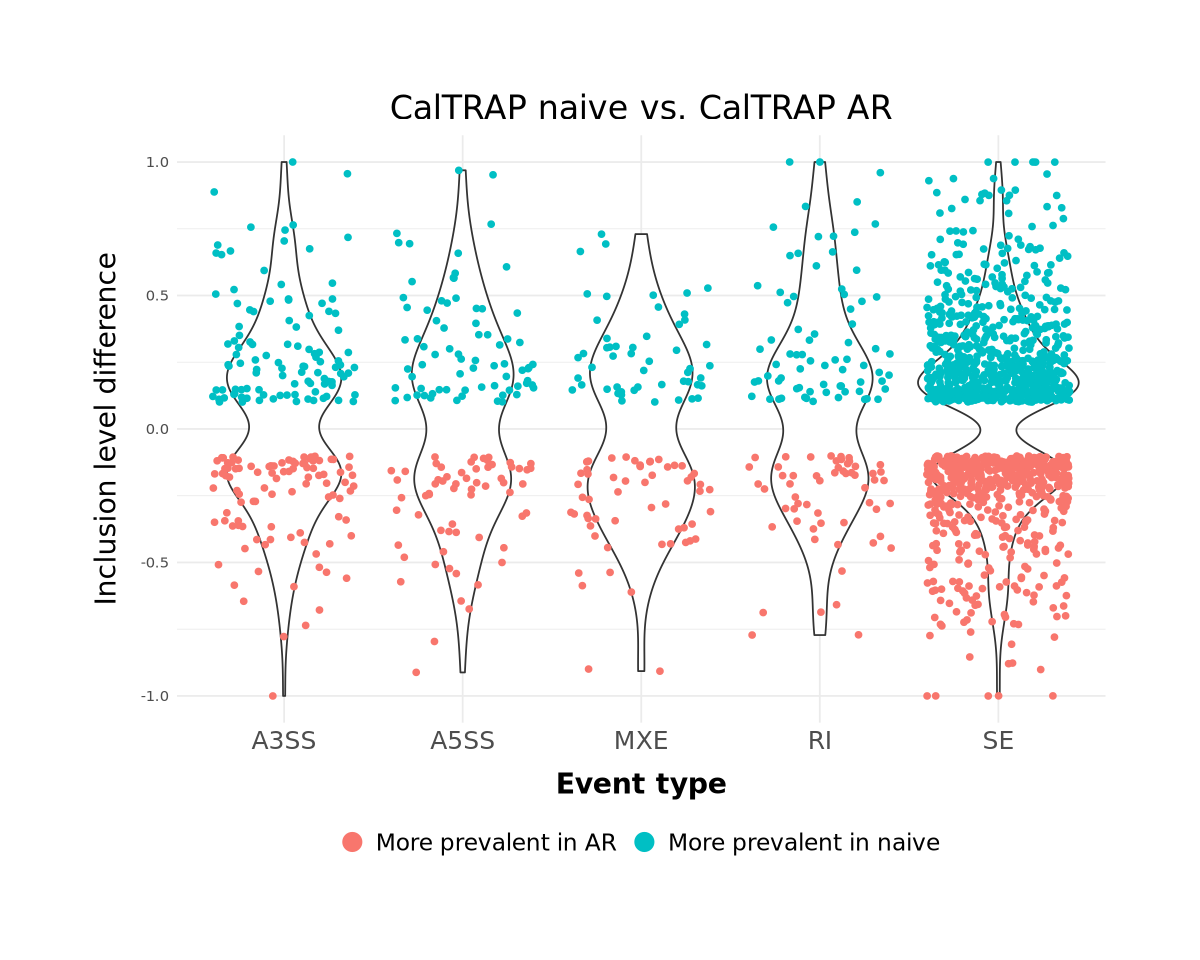

In [ ]:
# combine all singificant splicing events

experiment_path <- "data/rmats/naive_vs_AR"

signif_files <- list.files(path=experiment_path, pattern="filtered")

signif_events_list <- lapply(signif_files, function(x) {
    df <- fread(file.path(experiment_path, x), data.table=FALSE)
    df$Event_type <- unlist(strsplit(x, split=".", fixed=TRUE))[1]
    df
})
signif_events_df <- do.call(rbind.fill, signif_events_list)
signif_events_df$Status <- "More prevalent in AR"
signif_events_df$Status[signif_events_df$IncLevelDifference > 0] <- "More prevalent in naive"

ggplot(signif_events_df, aes(x=Event_type, y=IncLevelDifference)) +
    geom_violin() +
    geom_jitter(aes(color=Status)) +
    theme(
        plot.title=element_text(size=20, hjust=.5),
        axis.title.x=element_text(size=17, face="bold"),
        axis.text.x=element_text(size=15),
        axis.title.y=element_text(size=17)
    ) +
    labs(title="CalTRAP naive vs. CalTRAP AR") +
    xlab("Event type") +
    ylab("Inclusion level difference") +
    guides(color=guide_legend(override.aes=list(size=5)))